Question 3:

Orders are 1, 1, 2 respectively

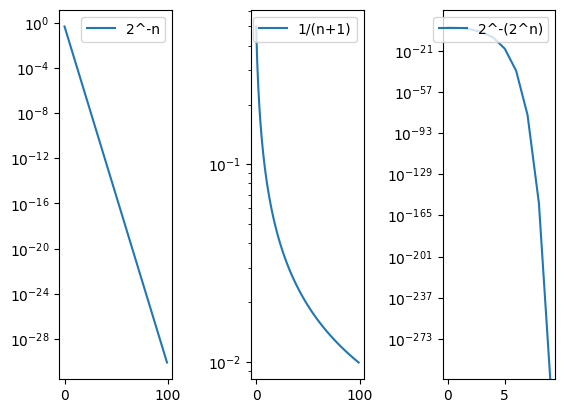

In [1]:
import matplotlib.pyplot as plt 

sequence1 = [(2**-n) for n in range(1,101)]
sequence2 = [(1/(n+1)) for n in range(1,101)]
sequence3 = [(2**-(2**n)) for n in range(1,11)]


figure, axis = plt.subplots(1, 3)
plt.subplots_adjust(wspace=0.7) 


axis[0].plot(sequence1, label='2^-n')
axis[1].plot(sequence2, label='1/(n+1)')
axis[2].plot(sequence3, label='2^-(2^n)')
for n in range(3):
  axis[n].set_yscale('log')
  axis[n].legend(loc='upper right')
  
plt.show()



<span style="color: SeaGreen; font-size: 32px;">Q3</span>

<span style="color: SeaGreen; font-size: 24px;">

Good work.

For (a), when the order of convergence is 1 and the rate is in $(0, 1)$, we say it is linear convergence.

For (b), when both the order of convergence and rate are 1, we would say it is sublinear convergence.

For (c), when the order of convergence is 2 and rate is in $(0, \infty)$, we would say it is quadratic convergence.

The difference in (a) and (b) is highlighted in the plots, even though that have the same value of $q$.

</span>

Question 4:
Yes
No
Yes
Reasoning on worksheet

<span style="color: SeaGreen; font-size: 32px;">Q4</span>

<span style="color: SeaGreen; font-size: 24px;">

Good work, correct for (a) and (b).

For (c), as we require more than $|g'(x)| < 1$ for all $x$, namely that the Lipschitz constant/ the supremum of all derivates is $< 1$, it is not a contration.

Would like to see more reasoning. (Endomorphism + Lipschitz constant check)

</span>

In [2]:
import mpmath

mpmath.mpf.dps = 100
pi = mpmath.pi

def leibnitz(n):
  pi_approx = mpmath.mpf(0)
  for k in range(0,n+1):
    pi_approx += ((-1)**k)/(2*k+1)
  approximations = [pi_approx , pi_approx + ((-1)**(n+1))/(2*(n+1)+1), pi_approx + ((-1)**(n+1))/(2*(n+1)+1) + ((-1)**(n+2))/(2*(n+2)+1)]
  return approximations

e_10000, e_10001, e_10002 = [abs(4*e - pi) for e in leibnitz(10000)]

q = mpmath.log(e_10002/e_10001)/mpmath.log(e_10001/e_10000)
m = e_10001/(e_10000**q)
print(f"q: {q}, m: {m}")

q: 0.999903396579754, m: 0.999010744761821


Conjecture: Its convergence order is 1

<span style="color: SeaGreen; font-size: 24px;">

(and rate is also 1, so precisely we conjecture it is sublinear)

</span>

Part C)

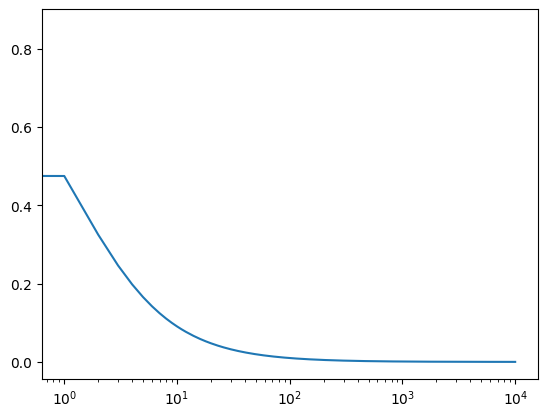

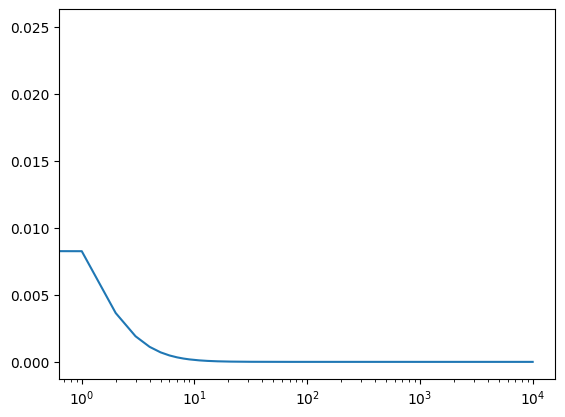

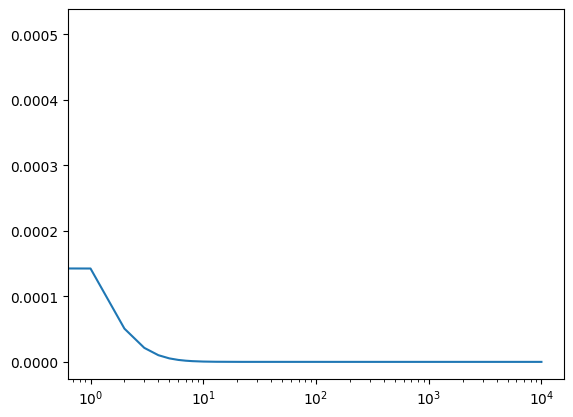

q_1: 0.99342653567126, q_2: 0.985230122827355


In [3]:
import matplotlib.pyplot as plt 
mpmath.mpf.dps = 100000

errors = []
errors_1 = []
errors_2 = []
a = []
a_1 = [] # 1st Aitken extrapolation
a_2 = [] # 2nd Aitken extrapolation

pi_approx = mpmath.mpf(0)
for n in range(1, 10001):
  pi_approx += ((-1)**(n-1))/(2*(n-1)+1)
  errors.append(abs(4*pi_approx - pi))
  a.append(4*pi_approx)

for n in range(0, len(a)-2):
  a_1.append(a[n] - ((a[n+1] - a[n])**2)/(a[n+2] - 2*a[n+1] + a[n]))
  errors_1.append(abs(a_1[n] - pi))

for n in range(0, len(a_1)-2):
  a_2.append(a_1[n] - ((a_1[n+1] - a_1[n])**2)/(a_1[n+2] - 2*a_1[n+1] + a_1[n]))
  errors_2.append(abs(a_2[n] - pi))


plt.plot(errors)
plt.xscale('log')
plt.show()

plt.plot(errors_1)
plt.xscale('log')
plt.show()

plt.plot(errors_2)
plt.xscale('log')
plt.show()

# Estimating e from 10000-> 10002 leads to errors due to computer precision, so using smaller.
q_1 = mpmath.log(errors_1[1002]/errors_1[1001])/mpmath.log(errors_1[1001]/errors_1[1000])
q_2 = mpmath.log(errors_2[102]/errors_2[101])/mpmath.log(errors_2[101]/errors_2[100])
print(f"q_1: {q_1}, q_2: {q_2}")


Conjecture: Aitken Acceleration preserves rate of convergence.

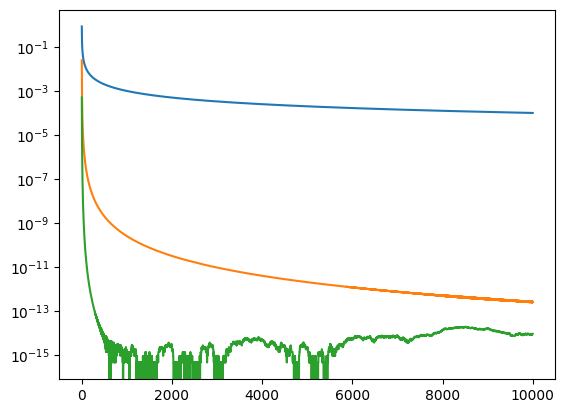

q_1: 0.99342653567126, q_2: 0.985230122827355


In [4]:
import matplotlib.pyplot as plt 
mpmath.mpf.dps = 100000

errors = []
errors_1 = []
errors_2 = []
a = []
a_1 = [] # 1st Aitken extrapolation
a_2 = [] # 2nd Aitken extrapolation

pi_approx = mpmath.mpf(0)
for n in range(1, 10001):
  pi_approx += ((-1)**(n-1))/(2*(n-1)+1)
  errors.append(abs(4*pi_approx - pi))
  a.append(4*pi_approx)

for n in range(0, len(a)-2):
  a_1.append(a[n] - ((a[n+1] - a[n])**2)/(a[n+2] - 2*a[n+1] + a[n]))
  errors_1.append(abs(a_1[n] - pi))

for n in range(0, len(a_1)-2):
  a_2.append(a_1[n] - ((a_1[n+1] - a_1[n])**2)/(a_1[n+2] - 2*a_1[n+1] + a_1[n]))
  errors_2.append(abs(a_2[n] - pi))


plt.plot(errors)
plt.plot(errors_1)
plt.plot(errors_2)

plt.yscale('log')

plt.show()

# Estimating e from 10000-> 10002 leads to errors due to computer precision, so using smaller.
q_1 = mpmath.log(errors_1[1002]/errors_1[1001])/mpmath.log(errors_1[1001]/errors_1[1000])
q_2 = mpmath.log(errors_2[102]/errors_2[101])/mpmath.log(errors_2[101]/errors_2[100])
print(f"q_1: {q_1}, q_2: {q_2}")


<span style="color: SeaGreen; font-size: 32px;">Q5</span>

<span style="color: SeaGreen; font-size: 24px;">

Great stuff, correct to observe:
- An order of convergence of 1 and rate/constant of 1 for all three, meaning all are sublinear (clear from log error against n plot)
- Each application of acceleration should improve the error by about 8 orders of magnitude, with little effect on how it's converging

There seems to be a slight error in the plot of the second application, as it shouldn't have precision issues with at least mpmath.mp.dps = 100.

I will investigate further, but need a bit more time, sorry.

</span>